In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.utils import to_categorical

In [ ]:
url = "https://drive.google.com/uc?id=1_S4l016r1rDniAOmZk8GKDKFSswpvZ4R"


data = pd.read_csv(url)
print(data.head())

   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      1       0       0       0       0       0       0       0       0   
3      4       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel783  
0         0         0         

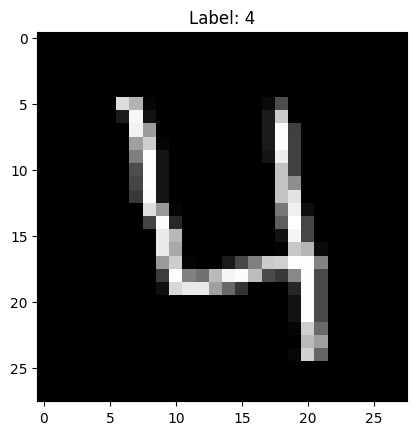

In [3]:
image_index = 3

image_values = data.iloc[image_index, 1:].values

image_matrix = image_values.reshape(28, 28)


plt.imshow(image_matrix, cmap='gray') 
plt.title(f"Label: {data.iloc[image_index, 0]}") 
plt.show() 

In [4]:

print("Shape of train_data:", data.shape)

pixel_data = data.iloc[:,  1:]

labels = data.iloc[:, 0]

print("Shape of pixel_data after separating features:", pixel_data.shape)

Shape of train_data: (42000, 785)
Shape of pixel_data after separating features: (42000, 784)


In [5]:
pixel_data = pixel_data.apply(pd.to_numeric, errors='coerce')

pixel_data = pixel_data.fillna(0)

pixel_data = pixel_data.values / 255.0

pixel_data = pixel_data.reshape(-1, 28, 28, 1)

print("Shape of pixel_data after reshaping:", pixel_data.shape)

Shape of pixel_data after reshaping: (42000, 28, 28, 1)


In [6]:
labels = to_categorical(labels, num_classes=10)

print("Shape of labels after one-hot encoding:", labels.shape)

Shape of labels after one-hot encoding: (42000, 10)


In [7]:
pixels_train, pixels_val, labels_train, labels_val = train_test_split(pixel_data, labels, test_size=0.2, random_state=42)
print("pixels_train shape:", pixels_train.shape)

pixels_train shape: (33600, 28, 28, 1)


In [8]:
model = Sequential([
    # Input Layer
    Input(shape=(28, 28, 1)),
    # Convert image to vector
    Flatten(),
    # Hidden layers
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    # Output layers
    Dense(10, activation='softmax')
])

model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])



model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    pixels_train,
    labels_train,
    epochs=10,
    batch_size=32,
    validation_data=(pixels_val, labels_val)
)

Epoch 1/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 659us/step - accuracy: 0.7918 - loss: 0.8012 - val_accuracy: 0.8887 - val_loss: 0.3924
Epoch 2/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 564us/step - accuracy: 0.9049 - loss: 0.3385 - val_accuracy: 0.9112 - val_loss: 0.3168
Epoch 3/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 562us/step - accuracy: 0.9201 - loss: 0.2805 - val_accuracy: 0.9225 - val_loss: 0.2824
Epoch 4/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 565us/step - accuracy: 0.9307 - loss: 0.2460 - val_accuracy: 0.9289 - val_loss: 0.2511
Epoch 5/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 564us/step - accuracy: 0.9368 - loss: 0.2203 - val_accuracy: 0.9370 - val_loss: 0.2278
Epoch 6/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 563us/step - accuracy: 0.9433 - loss: 0.1993 - val_accuracy: 0.9402 - val_loss: 0.2100
Epoch 7/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 600us/step - accuracy: 0.9478 - loss: 0.1827 - val_accuracy: 0.9423 - val_loss: 0.1985
Epoch 8/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 564us/step - accuracy: 0.9522 -

263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 376us/step - accuracy: 0.9501 - loss: 0.1713
Validation Accuracy: 95.01%


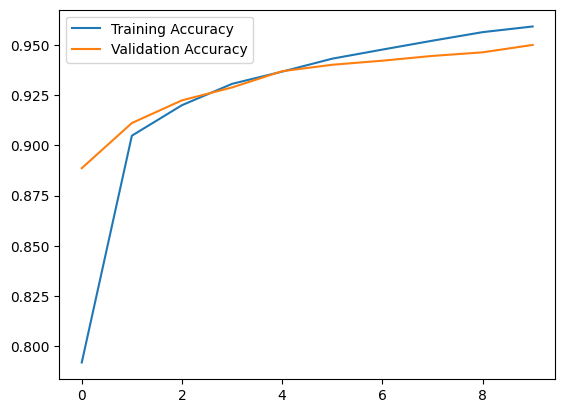

In [10]:
val_loss, val_accuracy = model.evaluate(pixels_val, labels_val)


print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 304us/step


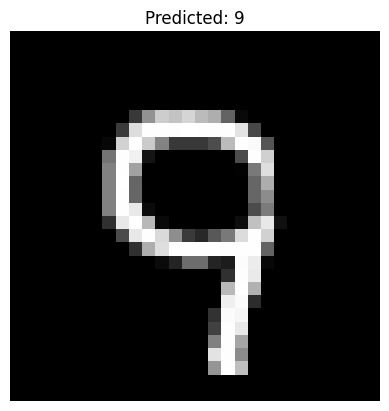

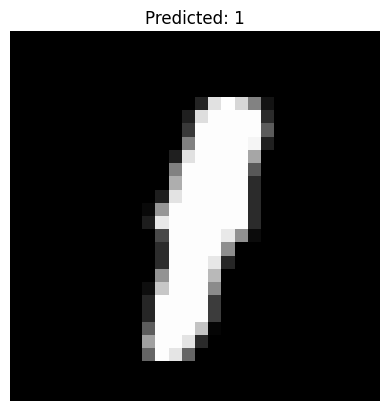

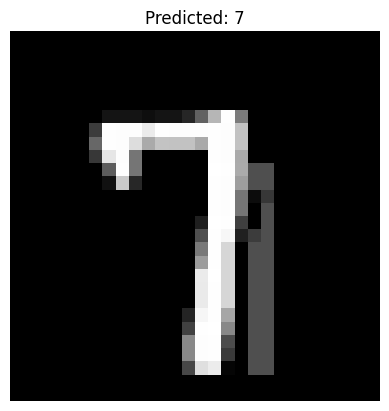

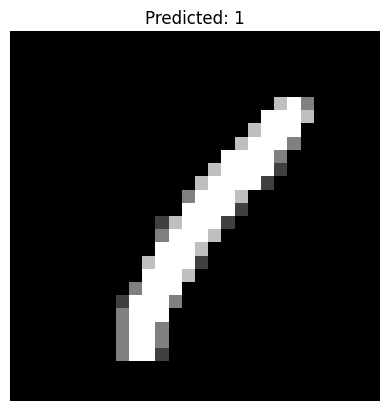

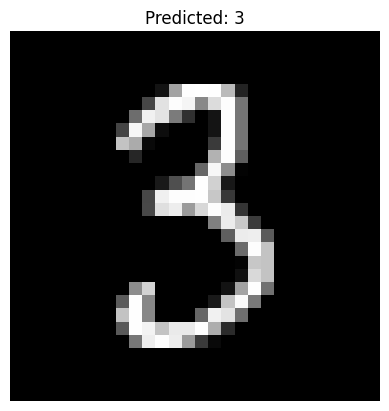

In [11]:
test_data = pd.read_csv('test.csv')

X_test = test_data.values / 255.0

X_test = X_test.reshape(-1, 28, 28, 1)

predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)



for i in range(5):
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {predicted_labels[i]}")
    plt.axis('off')
    plt.show()